We compare the performance of linear regularization methods applied to two-dimensional deconvolution problems:
We try to find a non-negative function f given data 
$$
    d \sim \mathrm{Pois}(h*f)
$$
with a non-negative convolution kernel $h$, and $\mathrm{Pois}$ denotes the element-wise Poisson distribution.

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mplib
from regpy.operators import CoordinateProjection 
from regpy.operators.convolution import ConvolutionOperator, GaussianBlur
from regpy.vecsps import UniformGridFcts
from regpy.solvers import RegularizationSetting
from regpy.solvers.linear.tikhonov import TikhonovCG, TikhonovAlphaGrid, NonstationaryIteratedTikhonov
from regpy.solvers.linear.landweber import Landweber
from regpy.hilbert import L2, HmDomain
import regpy.stoprules as rules
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-20s :: %(message)s'
)

We first introduce a plotting routine for comparing reconstructions and originals using the same color scale and access colors.  

In [115]:
def comparison_plot(grid,truth,reco,title_right='exact',title_left='reconstruction'):
    plt.rcParams.update({'font.size': 22})
    extent = [grid.axes[0][0],grid.axes[0][-1], grid.axes[1][0], grid.axes[1][-1]]
    maxval = np.max(truth[:]); minval = np.min(truth[:])
    mycmap = mplib.colormaps['hot']
    mycmap.set_over((0,0,1.,1.))  # use blue as access color for large values
    mycmap.set_under((0,1,0,1.))  # use green as access color for small values
    fig, (ax1,ax2) = plt.subplots(1,2,figsize = (22,8))
    im1= ax1.imshow(reco.T,extent=extent,origin='lower',
                    vmin=1.1*minval-0.1*maxval, vmax =1.1*maxval-0.1*minval,
                    cmap=mycmap
                    )
    ax1.title.set_text(title_left)
    fig.colorbar(im1,extend='both')
    im2= ax2.imshow(truth.T,extent=extent, origin='lower',
                    vmin=1.1*minval-0.1*maxval, vmax =1.1*maxval-0.1*minval,
                    cmap=mycmap
                    )
    ax2.title.set_text(title_right)
    fig.colorbar(im2,extend='both',orientation='vertical')

Define test objects 

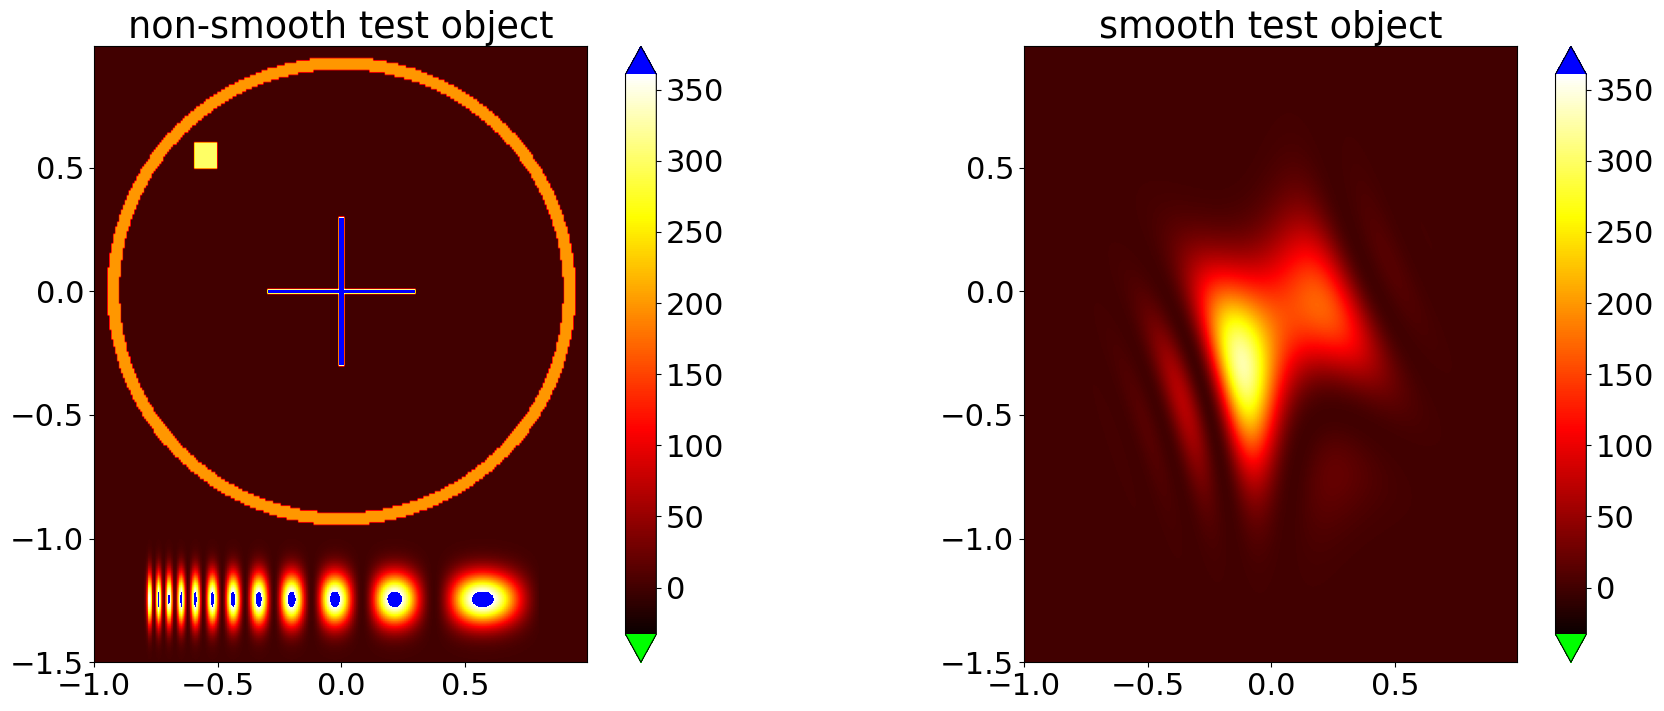

In [116]:
grid = UniformGridFcts((-1, 1, 256), (-1.5, 1, 256),dtype = float, periodic = True)
"""Space of real-valued functions on a uniform grid with rectangular pixels"""
X = grid.coords[0]; Y = grid.coords[1]
"""x and y coordinates."""
cross = 1.0*np.logical_or((abs(X)<0.01) * (abs(Y)<0.3),(abs(X)<0.3) * (abs(Y)<0.01)) 
rad = np.sqrt(X**2 + Y**2)
ring = 1.0*np.logical_and(rad>=0.9, rad<=0.95)
smallbox = (abs(X+0.55)<=0.05) * (abs(Y-0.55)<=0.05)
bubbles = (1.001+np.sin(50/(X+1.3)))*np.exp(-((Y+1.25)/0.1)**2)*(X>-0.8)*(X<0.8)

hills = 200*(1+  np.sin(100*(Y*X+X**2)))*np.exp(-(X/0.3)**2 - ((Y+0.25)/0.4)**2)
hills2 =  200*(1+  np.sin(25*(Y*X+X**2)))*np.exp(-(X/0.3)**2 - ((Y+0.25)/0.4)**2)

objects = 200*(ring + 2.0*cross + 1.5*smallbox + bubbles)
exact_sol = hills2
 
comparison_plot(grid,hills2,objects,title_left='non-smooth test object',title_right='smooth test object')


Create convolution operator and noisy simulated data

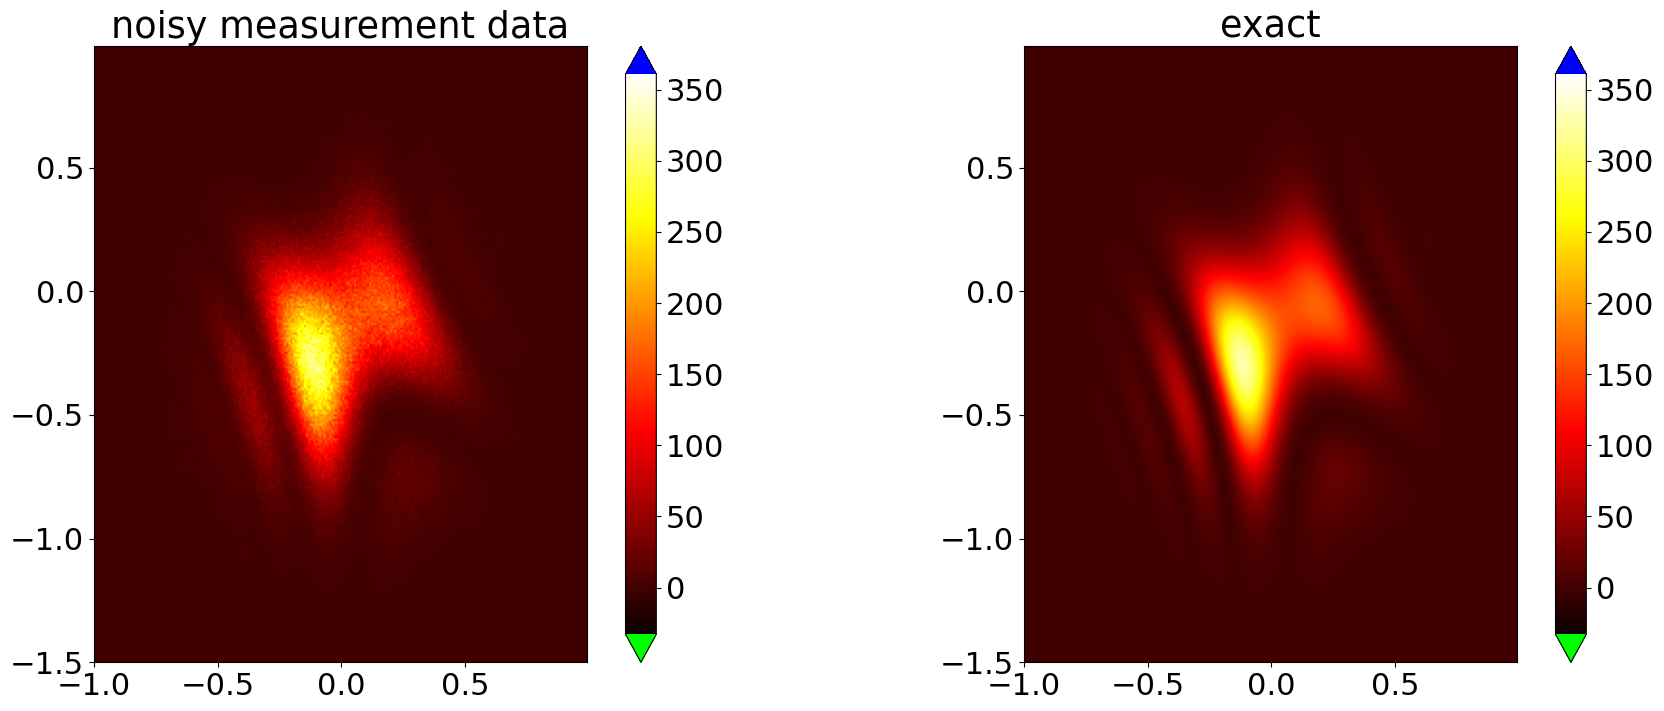

In [117]:
a=0.05
conv = GaussianBlur(grid,a)
"""Convolution operator \(f\mapsto h*f\) for the convolution kernel \(h(x)=\exp(-|x|^2/a^2)\)."""

blur = conv(exact_sol)
blur[blur<0] = 0.
"""Simulated exact data."""
data = np.random.poisson(blur)
"""Simulated measured data. The Poisson distribution occurs if photon count detectors are used."""
comparison_plot(grid,exact_sol,data,title_left='noisy measurement data')

We first apply Tikhonov regularization in Fourier space. Recall that a convolution operator is given in Fourier space by $T=F^* M_H F$ with a multiplication operator $M_H$, and the multiplier function $H$, often called object transfer function, is the Fourier transform of the convolution kernel. Hence, the Tikhonov estimator has the following simple representation in Fourier space:
$$
(T^*T+\alpha I)^{-1}T^* =  F^* M_r F \qquad \text{with}\qquad r = \frac{\overline{H}}{\alpha + |H|^2} \approx \frac{1}{H}.
$$
We choose $\alpha$ by Morozov's discrepancy principle, i.e. (roughly) the largest value for which the residual $\|Tf-\mathrm{data}\|$ is smaller than the noise level.
Since for Poisson distributed random variable the expectation equals the variance, the noiselevel can be estimated by
$$
 \|\mathrm{data}-\mathrm{blur}\|_2  \approx \|\sqrt{\mathrm{data}}\|_2.
$$

alpha= 0.5 rel. discrepancy= 6.044572544270123
alpha= 0.25 rel. discrepancy= 4.148465840242973
alpha= 0.125 rel. discrepancy= 2.6423609323271804
alpha= 0.0625 rel. discrepancy= 1.6977331897700532
alpha= 0.03125 rel. discrepancy= 1.237653969536873
alpha= 0.015625 rel. discrepancy= 1.0660967744828846
alpha= 0.0078125 rel. discrepancy= 1.0132556556268035
relative reconstruction error: 0.07158580033848273


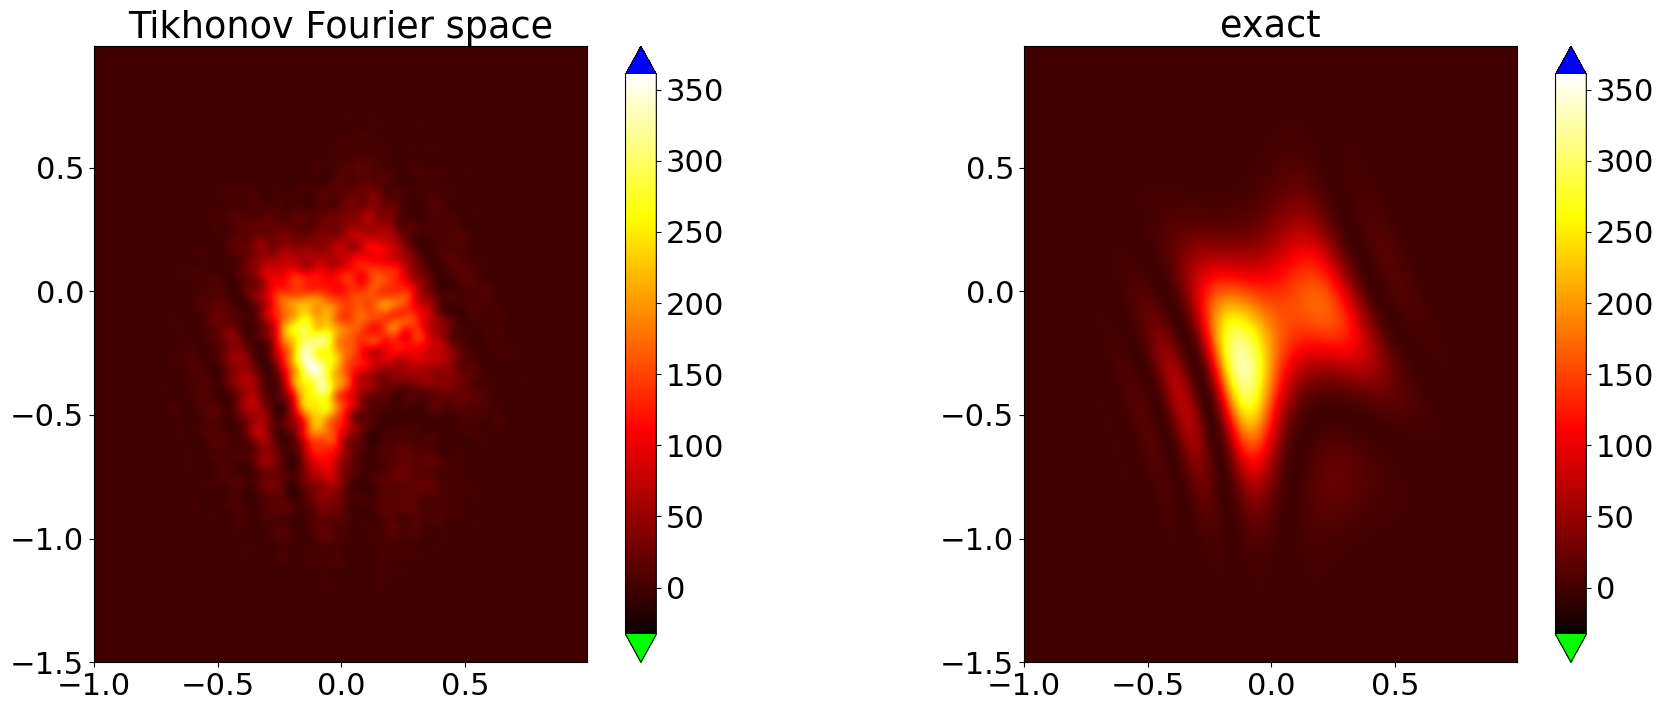

In [118]:
alpha = 1e-0
# inital regularization parameter. (Should be chosen too large.)
otf = conv.fourier_multiplier
# The Fourier transform of the convolution kernel, often called "object transfer function"
reco_op= ConvolutionOperator(grid, np.conj(otf)/(np.abs(otf)**2+alpha))
# The Tikhonov reconstruction operator
reco = reco_op(data)
# Estimator of the true solution
it=0
while np.linalg.norm(conv(reco)[:]-data[:])>np.linalg.norm(np.sqrt(data[:])) and it <20:
    it = it+1
    alpha = alpha/2
    print('alpha=',alpha, 'rel. discrepancy=', np.linalg.norm(conv(reco)[:]-data[:])/np.linalg.norm(np.sqrt(data[:])))
    reco_op= ConvolutionOperator(grid, np.conj(otf)/(np.abs(otf)**2+alpha))
    reco = reco_op(data)

print('relative reconstruction error:', np.linalg.norm(reco[:]-exact_sol[:])/np.linalg.norm(exact_sol[:]))
comparison_plot(grid,exact_sol,reco,title_left='Tikhonov Fourier space')

We now use Landweber iteration 
$$
f_{n+1} = f_n - \mu T^*(Tf_{n}-\mathrm{data}), n=0,1,2
$$
and again stop the iteration by the discrepancy principle. The step-length parameter is chosen $\mu= 1/\|T^*T\|$ where the operator norm (equal to the largest eigenvalue) is estimated by Lanczos' method. 

2024-04-17 13:49:30,428 INFO CountIterations      :: iteration = 0 / 1000
2024-04-17 13:49:30,430 INFO Discrepancy          :: relative discrepancy = 11.61, tolerance = 1.00
2024-04-17 13:49:30,441 INFO Landweber            :: |residual| = 104.41159603860628
2024-04-17 13:49:30,442 INFO CountIterations      :: iteration = 1 / 1000
2024-04-17 13:49:30,444 INFO Discrepancy          :: relative discrepancy = 1.55, tolerance = 1.00
2024-04-17 13:49:30,455 INFO Landweber            :: |residual| = 13.927258652764435
2024-04-17 13:49:30,456 INFO CountIterations      :: iteration = 2 / 1000
2024-04-17 13:49:30,458 INFO Discrepancy          :: relative discrepancy = 1.10, tolerance = 1.00
2024-04-17 13:49:30,471 INFO Landweber            :: |residual| = 9.921136795946866
2024-04-17 13:49:30,473 INFO CountIterations      :: iteration = 3 / 1000
2024-04-17 13:49:30,477 INFO Discrepancy          :: relative discrepancy = 1.03, tolerance = 1.00
2024-04-17 13:49:30,490 INFO Landweber            :: 

relative reconstruction error: 0.02232842089751755


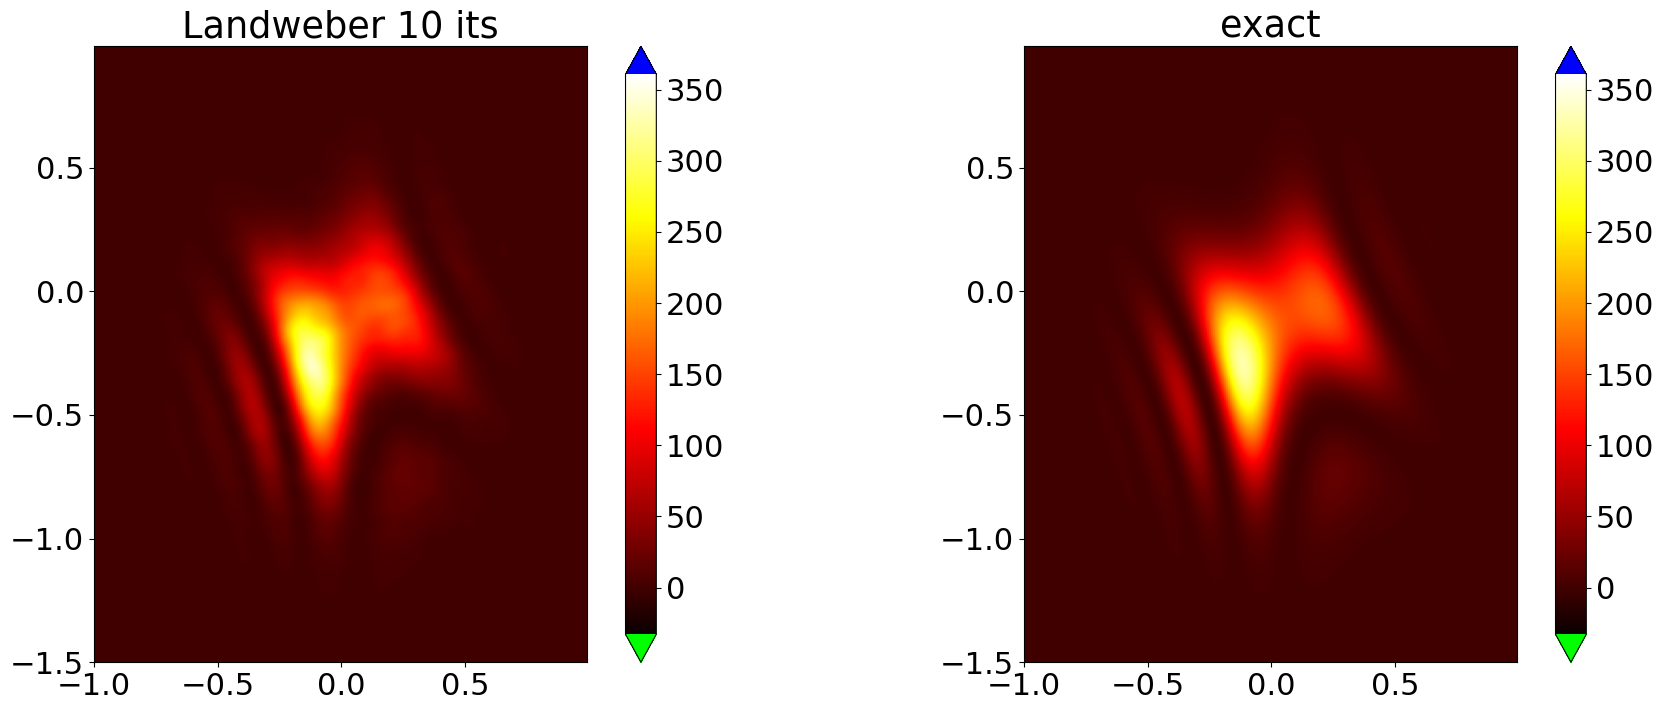

In [119]:
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=L2)
solver = Landweber(setting, data,grid.zeros())
max_its= 1000
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=L2)
stoprule =  (rules.CountIterations(max_iterations=max_its)
   +rules.Discrepancy(setting.h_codomain.norm, data,
        noiselevel=setting.h_codomain.norm(np.sqrt(data[:])), tau=1.0)
)
reco, reco_data = solver.run(stoprule)
print('relative reconstruction error:', np.linalg.norm(reco[:]-exact_sol[:])/np.linalg.norm(exact_sol[:]))
comparison_plot(grid,exact_sol,reco,title_left="Landweber {} its".format(solver.iteration_step_nr))

We now choose the Gram matrix in the image space as approximation of the covariance matrix of the data. Recall that the true covariance matrix for Poisson data is the diagonal matrix with the expectation as diagonal.This requires many more Landweber iterations, but (often) leads to some improvement of the reconstruction error. 

2024-04-17 13:49:33,073 INFO CountIterations      :: iteration = 0 / 1000
2024-04-17 13:49:33,075 INFO Discrepancy          :: relative discrepancy = 11.61, tolerance = 1.00
2024-04-17 13:49:33,089 INFO Landweber            :: |residual| = 1434.7376194772214
2024-04-17 13:49:33,090 INFO CountIterations      :: iteration = 1 / 1000
2024-04-17 13:49:33,092 INFO Discrepancy          :: relative discrepancy = 3.85, tolerance = 1.00
2024-04-17 13:49:33,105 INFO Landweber            :: |residual| = 359.1389469267692
2024-04-17 13:49:33,106 INFO CountIterations      :: iteration = 2 / 1000
2024-04-17 13:49:33,108 INFO Discrepancy          :: relative discrepancy = 2.47, tolerance = 1.00
2024-04-17 13:49:33,121 INFO Landweber            :: |residual| = 209.77909036713905
2024-04-17 13:49:33,122 INFO CountIterations      :: iteration = 3 / 1000
2024-04-17 13:49:33,124 INFO Discrepancy          :: relative discrepancy = 1.90, tolerance = 1.00
2024-04-17 13:49:33,137 INFO Landweber            :: 

relative reconstruction error: 0.1550727514505547


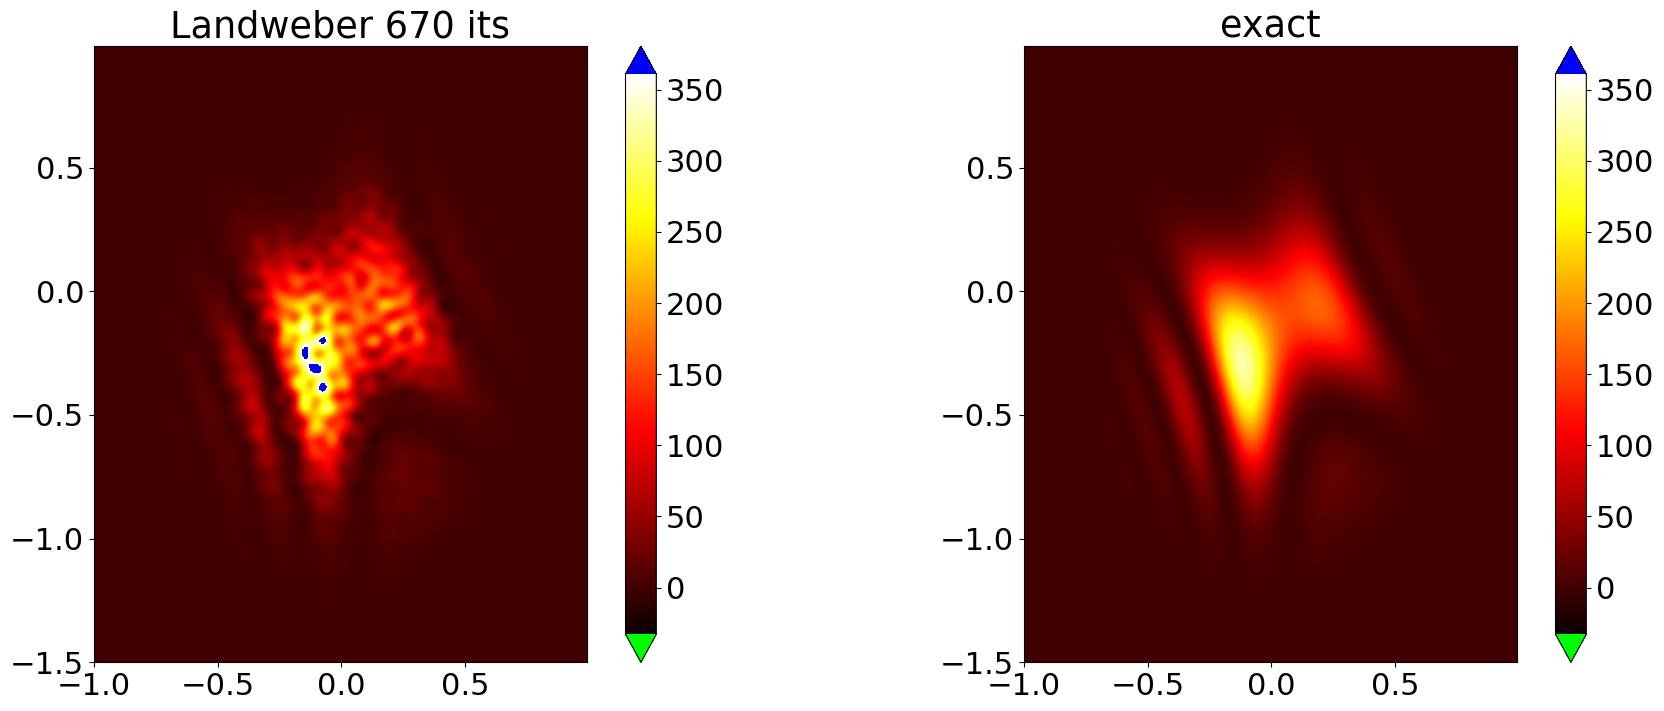

In [120]:
h_codomain = L2(grid, weights = 1.+data) 
# We estimate the expectation (i.e. blur) by the data and add 1 to avoid zeros.
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=h_codomain)
solver = Landweber(setting, data,grid.zeros())
max_its= 1000
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=L2)
stoprule =  (rules.CountIterations(max_iterations=max_its)
   +rules.Discrepancy(setting.h_codomain.norm, data,
        noiselevel=setting.h_codomain.norm(np.sqrt(data[:])), tau=1.0)
)
reco, reco_data = solver.run(stoprule)
print('relative reconstruction error:', np.linalg.norm(reco[:]-exact_sol[:])/np.linalg.norm(exact_sol[:]))
comparison_plot(grid,exact_sol,reco,title_left="Landweber {} its".format(solver.iteration_step_nr))

We now apply Tikhonov regularization with norm in the image space approximating the covariance matrix of the data and hence the negative log-likelihood. 
In this case the Tikhonov estimator can no longer be computed in Fourier space. Instead, we minimize the Tikhonov functional by the conjugate gradient method. The regularization parameter is again chosen by the discrepancy principle. Similar results are obtained by iterated Tikhonov regularization 
$$
f_{n+1} = \mathrm{argmin}_f \left[\|Tf-\mathrm{data}\|^2+ \alpha_n \|f-f_n\|^2\right].
$$

2024-04-17 13:49:53,984 INFO CountIterations      :: iteration = 0 / 50
2024-04-17 13:49:54,004 INFO Discrepancy          :: relative discrepancy = 11.61, tolerance = 1.02
2024-04-17 13:49:54,576 INFO NonstationaryIteratedTikhonov :: alpha_eff = 0.01, inner CG its = 8
2024-04-17 13:49:54,578 INFO CountIterations      :: iteration = 1 / 50
2024-04-17 13:49:54,582 INFO Discrepancy          :: relative discrepancy = 1.02, tolerance = 1.02
2024-04-17 13:49:54,727 INFO NonstationaryIteratedTikhonov :: alpha_eff = 0.0033333333333333335, inner CG its = 9
2024-04-17 13:49:54,729 INFO CountIterations      :: iteration = 2 / 50
2024-04-17 13:49:54,733 INFO Discrepancy          :: relative discrepancy = 1.01, tolerance = 1.02
2024-04-17 13:49:54,734 INFO CombineRules         :: Rule Discrepancy(noiselevel=8.99155199073822, tau=1.02) triggered.
2024-04-17 13:49:54,735 INFO NonstationaryIteratedTikhonov :: Solver converged after 2 iteration.


relative reconstruction error: 0.04949445947379612


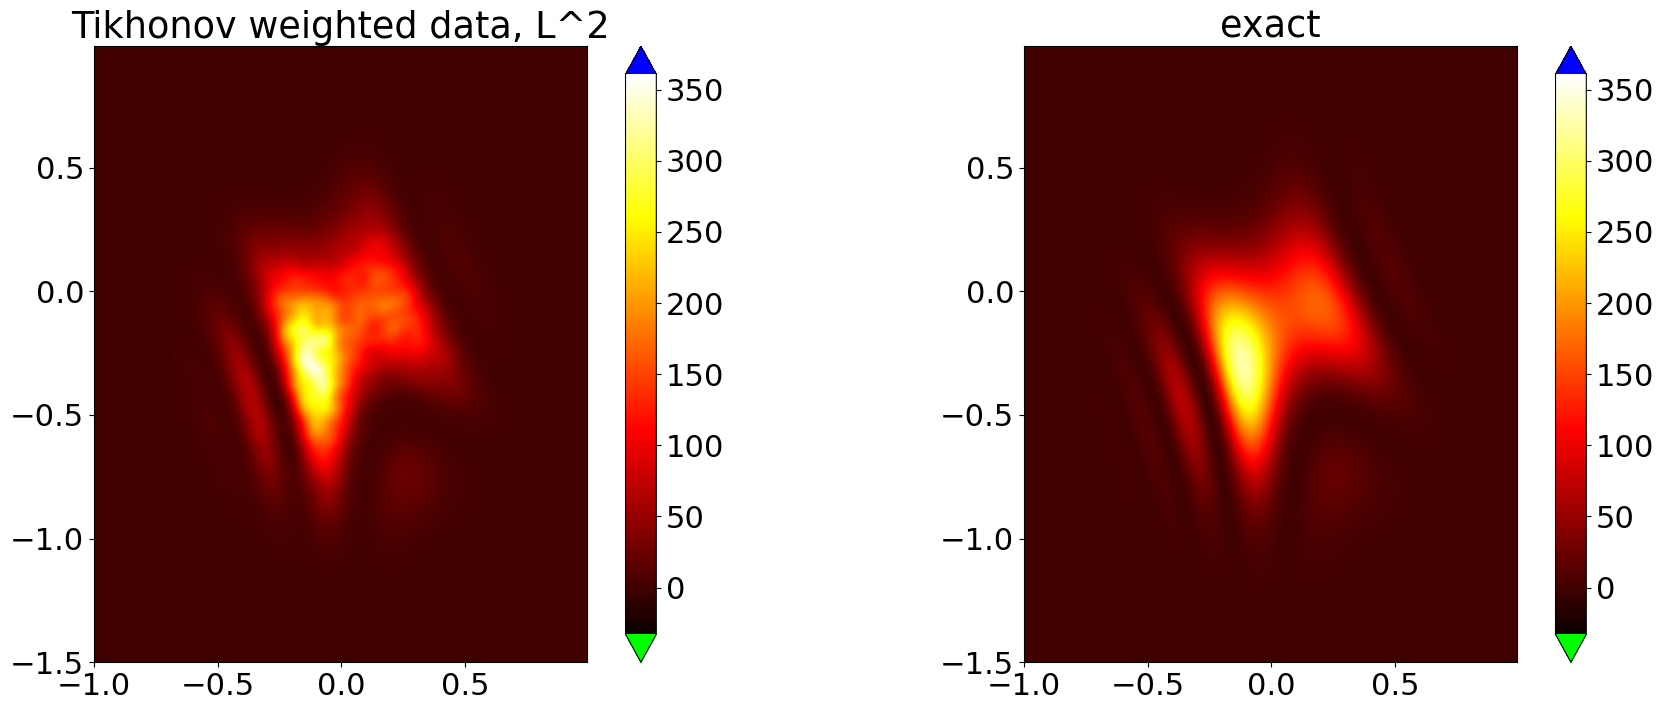

In [121]:
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=h_codomain)
#solver = TikhonovAlphaGrid(setting,data,(1e-2,0.5))
solver = NonstationaryIteratedTikhonov(setting,data,(1e-2,0.5))
max_its= 50
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=L2)
stoprule =  (rules.CountIterations(max_iterations=max_its)
   +rules.Discrepancy(setting.h_codomain.norm, data,
        noiselevel=setting.h_codomain.norm(np.sqrt(data[:])), tau=1.02)
)
reco, reco_data = solver.run(stoprule)
print('relative reconstruction error:', np.linalg.norm(reco[:]-exact_sol[:])/np.linalg.norm(exact_sol[:]))
comparison_plot(grid,exact_sol,reco,title_left="Tikhonov weighted data, L^2")


Finally, we restrict the unknown function to some subdomain $D$ containing the support of the true function (can be the whole domain) and use a Sobolev penalty term. The corresponding inner product is given by 
$$
\langle f_1,f_2\rangle_{H^m(D)} = \langle f_1, (I-\Delta)^{-m} f_w \rangle_{L^2(D)} 
$$
with the Laplace operator $\Delta$ and some index $m=0,1,2,...$. By default, Dirichlet boundary conditions are imposed on the boundary of $\partial D$. If $D$ shares part or all of the boundary with the full rectangle, Neumann boundary conditions are imposed on these parts

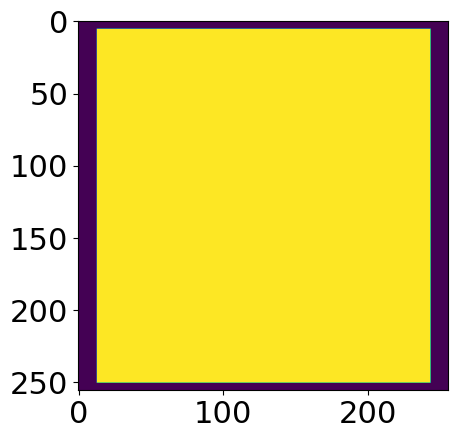

In [122]:
#largebox = np.logical_and(abs(X)<=1.1,(abs(Y+0.25)<=1.5))
largebox = np.logical_and(abs(X)<=0.9,(abs(Y+0.25)<=1.2))
plt.imshow(largebox.T)
emb = CoordinateProjection(grid,largebox).adjoint

2024-04-17 13:49:59,403 INFO CountIterations      :: iteration = 0 / 50
2024-04-17 13:49:59,411 INFO Discrepancy          :: relative discrepancy = 13.69, tolerance = 1.00
2024-04-17 13:50:01,561 INFO TikhonovAlphaGrid    :: alpha = 1e-06, inner CG its = 7
2024-04-17 13:50:01,565 INFO CountIterations      :: iteration = 1 / 50
2024-04-17 13:50:01,569 INFO Discrepancy          :: relative discrepancy = 1.54, tolerance = 1.00
2024-04-17 13:50:02,918 INFO TikhonovAlphaGrid    :: alpha = 3.333333333333333e-07, inner CG its = 8
2024-04-17 13:50:02,921 INFO CountIterations      :: iteration = 2 / 50
2024-04-17 13:50:02,924 INFO Discrepancy          :: relative discrepancy = 1.39, tolerance = 1.00
2024-04-17 13:50:03,691 INFO TikhonovAlphaGrid    :: alpha = 1.111111111111111e-07, inner CG its = 10
2024-04-17 13:50:03,693 INFO CountIterations      :: iteration = 3 / 50
2024-04-17 13:50:03,698 INFO Discrepancy          :: relative discrepancy = 1.20, tolerance = 1.00
2024-04-17 13:50:04,820 INF

relative reconstruction error: 0.045695801081250514


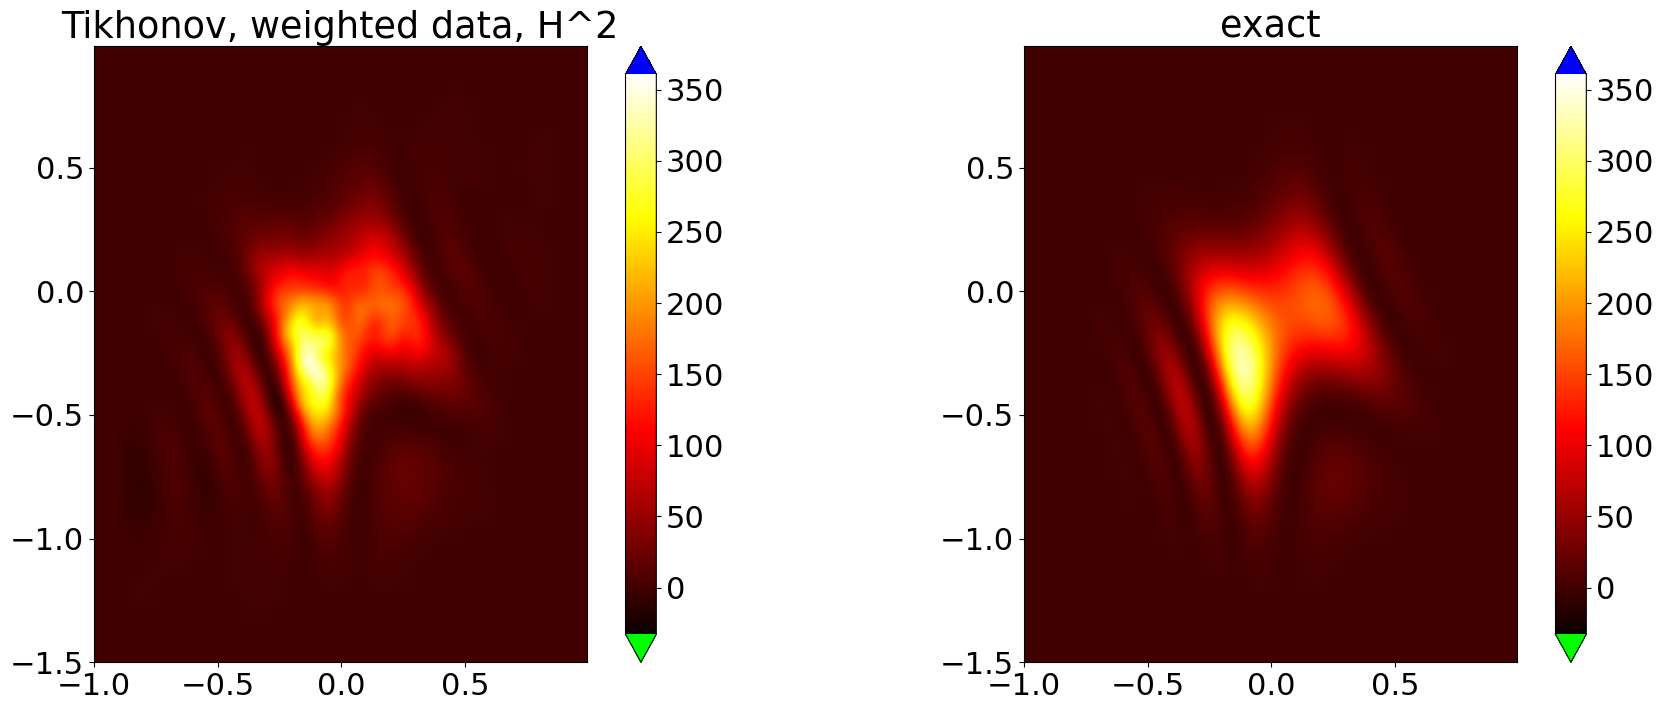

In [123]:
m=2; pen = HmDomain(grid, largebox, index = m)
# Sobolev space on the domain D given by largebox of index m
setting = RegularizationSetting(op=conv*emb, penalty=pen, data_fid=h_codomain)
solver = TikhonovAlphaGrid(setting,data,(1e-6,1/3))
max_its= 50
stoprule =  (rules.CountIterations(max_iterations=max_its)
   +rules.Discrepancy(setting.h_codomain.norm, data,
        noiselevel=setting.h_codomain.norm(np.sqrt(data[:])), tau=1.0)
)
reco, reco_data = solver.run(stoprule)
print('relative reconstruction error:', np.linalg.norm(emb(reco)[:]-exact_sol[:])/np.linalg.norm(exact_sol[:]))
comparison_plot(grid,exact_sol,emb(reco),title_left="Tikhonov, weighted data, H^{}".format(m))